# PERCOBAAN TANPA PREPROCESSING
Percobaan ini membandingkan klasifikasi citra **catterpillar** dan **snail** dengan data citra asli (raw image). Dataset terdiri dari 140 citra, yaitu 70 citra pada setiap kelas, sehingga distribusi kelas seimbang dan metrik akurasi tidak terdorong oleh kelas mayoritas. Alur percobaan mencakup pemuatan data, tanpa augmentasi dan preprocessing eksternal, ekstraksi fitur tekstur GLCM, seleksi fitur berbasis korelasi, pembagian data, standardisasi, pelatihan model, serta evaluasi. Citra tetap memiliki ukuran, pencahayaan, noise, latar belakang, dan variasi pengambilan gambar sebagaimana pada dataset awal. Konversi ke grayscale di dalam fungsi ekstraksi fitur dilakukan agar GLCM dapat menghitung tekstur intensitas, sehingga bukan berarti terdapat pipeline preprocessing citra seperti resize, denoising, atau equalization.

# IMPORT LIBRARY

In [141]:
# Import library yang dibutuhkan
import os
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import entropy
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

Mengimpor library untuk pengelolaan berkas, komputasi numerik, manipulasi tabel, visualisasi, ekstraksi fitur, pemisahan data, pemodelan, dan evaluasi. `OpenCV` digunakan untuk membaca citra serta mengubah citra berwarna menjadi grayscale saat fitur GLCM diekstraksi. `NumPy` dan `Pandas` menopang pengolahan array citra dan tabel fitur, sedangkan `Matplotlib` serta `Seaborn` dipakai untuk menampilkan contoh citra dan korelasi fitur. `scikit-image` menyediakan `graycomatrix` dan `graycoprops`, yaitu komponen utama untuk memperoleh karakteristik tekstur. `scikit-learn` menyediakan tiga model pembanding—Random Forest, SVM, dan KNN—beserta metrik yang diperlukan untuk mengukur kualitas hasil training dan testing.

## Data Loading

In [142]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print("Folder dataset:", DATASET_DIR.resolve())


Folder dataset: D:\AAAAA KULIAH\SEM 4\PECEDE\Project-PCD-Kelompok-16\dataset


In [1]:
data = []
labels = []
file_name = []

for class_folder in sorted(DATASET_DIR.iterdir()):
    if not class_folder.is_dir():
        continue

    label = class_folder.name
    image_files = [
        file for file in sorted(class_folder.iterdir())
        if file.suffix.lower() in VALID_EXTENSIONS
    ]

    print(f"{label}: {len(image_files)} gambar")

    for image_path in image_files:
        image = cv.imread(str(image_path))

        if image is None:
            print("Gagal membaca gambar:", image_path)
            continue

        data.append(image.astype(np.uint8))
        labels.append(label)
        file_name.append(image_path.name)

data = np.array(data, dtype=object)
labels = np.array(labels)
file_name = np.array(file_name)

print("\nTotal data:", len(data))
print(pd.Series(labels).value_counts())

NameError: name 'DATASET_DIR' is not defined

Menetapkan direktori dataset dari lokasi kerja proyek dan membatasi ekstensi citra yang dapat dibaca ke JPG, JPEG, PNG, dan BMP. Cell 4 kemudian menelusuri setiap subfolder kelas secara terurut, membaca setiap citra yang valid, lalu menyimpan citra, label, dan nama berkas secara paralel. Hasil pemuatan menunjukkan bahwa folder `catterpillar` berisi 70 gambar dan folder `snail` juga berisi 70 gambar, dengan total 140 gambar. Keseimbangan 70:70 penting karena model memperoleh contoh yang sama banyak dari kedua kelas dan accuracy dapat ditafsirkan lebih adil. Citra disimpan sebagai `uint8` dan belum diseragamkan ukurannya atau kualitasnya, sehingga karakteristik awal setiap file tetap dipertahankan untuk percobaan raw-data ini.

## Data Augmentation

In [144]:
# Percobaan ini tidak memakai augmentation agar data tetap citra asli tanpa preprocessing.
def augment_image(image):
    return []

In [145]:
USE_AUGMENTATION = False

data_used = list(data)
labels_used = list(labels)
file_name_used = list(file_name)

if USE_AUGMENTATION:
    for image, label, filename in zip(data, labels, file_name):
        for index, augmented_image in enumerate(augment_image(image), start=1):
            data_used.append(augmented_image.astype(np.uint8))
            labels_used.append(label)
            name, ext = os.path.splitext(filename)
            file_name_used.append(f"{name}_aug{index}{ext}")

data_used = np.array(data_used, dtype=object)
labels_used = np.array(labels_used)
file_name_used = np.array(file_name_used)

print("Data sebelum augmentasi:", len(data))
print("Data yang digunakan:", len(data_used))

Data sebelum augmentasi: 140
Data yang digunakan: 140


Fungsi `augment_image` sengaja mengembalikan daftar kosong karena tujuan eksperimen adalah menguji citra asli tanpa augmentasi. Variabel `USE_AUGMENTATION` juga bernilai `False`, sehingga blok penambahan hasil rotasi, flip, perubahan pencahayaan, atau transformasi lain tidak dijalankan. Output mengonfirmasi bahwa jumlah data sebelum augmentasi adalah 140 dan jumlah data yang digunakan tetap 140. Keputusan ini membuat perbedaan performa model dapat dikaitkan langsung dengan karakteristik data raw, bukan dengan citra sintetis tambahan. Namun, tidak adanya augmentasi berarti model memiliki paparan variasi visual yang lebih terbatas dan bisa lebih sensitif terhadap perubahan posisi, orientasi, skala, atau pencahayaan pada citra baru.

### Menampilkan Gambar Dataset

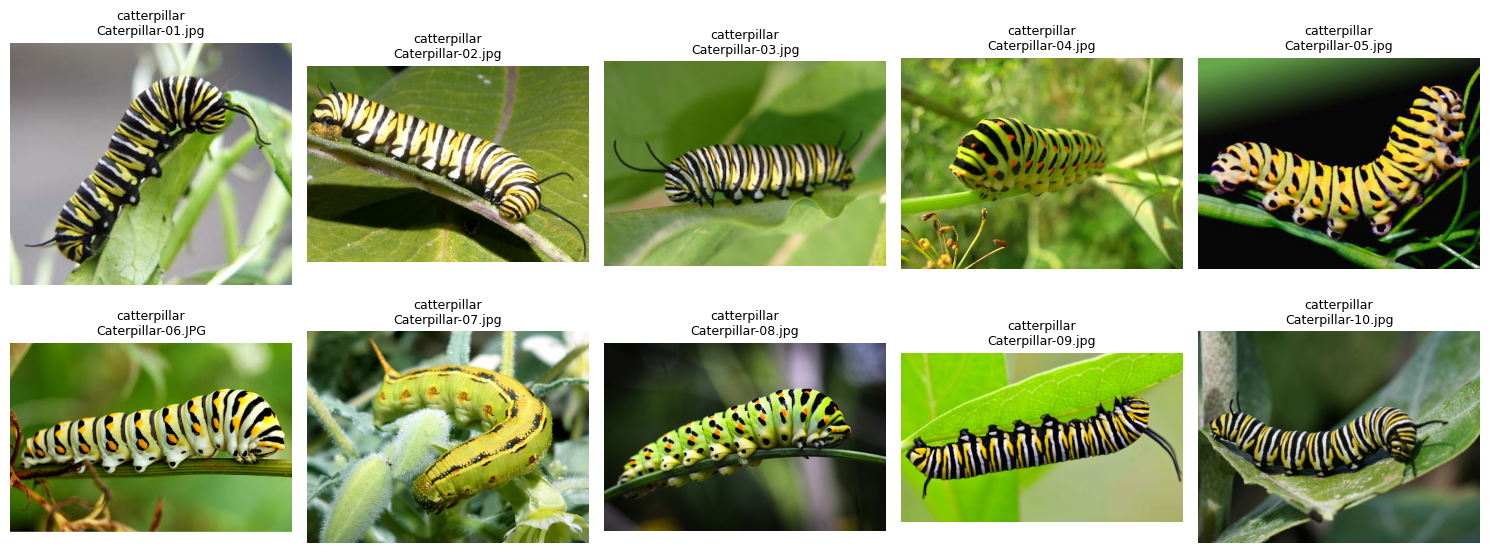

In [146]:
# Menampilkan 10 contoh gambar sebelum data preparation
jumlah_gambar = min(10, len(data_used))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.axis("off")

    if i < jumlah_gambar:
        image = data_used[i]
        if image.ndim == 3:
            image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
            ax.imshow(image)
        else:
            ax.imshow(image, cmap="gray")
        ax.set_title(f"{labels_used[i]}\n{file_name_used[i]}", fontsize=9)

plt.tight_layout()
plt.show()


Visualisasi menampilkan maksimal sepuluh citra awal lengkap dengan label dan nama berkasnya untuk pemeriksaan awal data. Langkah ini bermanfaat untuk memastikan pembacaan citra berhasil dan label yang dipasangkan pada setiap gambar tidak tertukar. Karena citra ditampilkan dalam RGB setelah dibaca OpenCV dalam format BGR, warna visualisasi dapat diinterpretasikan dengan benar oleh `matplotlib`. Pada tahap ini belum ada transformasi yang mengubah isi citra selain konversi format warna khusus untuk tujuan tampilan. Keragaman tampilan antar-citra yang terlihat pada sampel perlu diperhatikan karena seluruh variasi tersebut akan masuk ke perhitungan fitur tekstur pada data raw.

## Data Preparation

### Feature Extraction

In [147]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Derajat harus salah satu dari: 0, 45, 90, 135.")

    return graycomatrix(
        image,
        distances=[1],
        angles=angles,
        levels=256,
        symmetric=True,
        normed=True,
    )


def safe_value(value):
    value = float(value)
    if np.isnan(value) or np.isinf(value):
        return 0.0
    return value

Fungsi ini mendefinisikan fungsi pembentuk Gray-Level Co-occurrence Matrix (GLCM) pada empat arah, yaitu 0°, 45°, 90°, dan 135°. Jarak piksel ditetapkan satu, sehingga fitur yang dihasilkan terutama menggambarkan hubungan tekstur antar-piksel yang berdekatan. Parameter `levels=256` mempertahankan seluruh rentang intensitas `uint8` dari citra grayscale tanpa melakukan kuantisasi tambahan untuk mereduksi variasi data raw. Opsi `symmetric=True` menghitung pasangan intensitas secara dua arah, sedangkan `normed=True` mengubah frekuensi pasangan menjadi distribusi yang dapat dibandingkan antar-citra. Fungsi `safe_value` mengganti nilai `NaN` atau tak hingga dengan nol, sehingga proses ekstraksi tidak gagal apabila citra tertentu menghasilkan perhitungan statistik yang tidak stabil. Karena belum ada denoising, resize, atau peningkatan kontras, GLCM juga menangkap noise, detail latar belakang, dan perbedaan resolusi yang terdapat pada citra asli. Dampaknya adalah fitur dapat menyimpan pola visual yang kaya, tetapi varians fitur antarcitra dalam kelas yang sama juga berpotensi meningkat. Dalam konteks hasil akhir, pemilihan arah dan mekanisme pengaman ini memungkinkan semua 140 citra diproses konsisten sebelum training dan testing dilakukan.

In [148]:
def correlation(matriks):
    return safe_value(graycoprops(matriks, "correlation")[0, 0])


def dissimilarity(matriks):
    return safe_value(graycoprops(matriks, "dissimilarity")[0, 0])


def homogenity(matriks):
    return safe_value(graycoprops(matriks, "homogeneity")[0, 0])


def contrast(matriks):
    return safe_value(graycoprops(matriks, "contrast")[0, 0])


def ASM(matriks):
    return safe_value(graycoprops(matriks, "ASM")[0, 0])


def energy(matriks):
    return safe_value(graycoprops(matriks, "energy")[0, 0])


def entropyGlcm(matriks):
    return safe_value(entropy(matriks.ravel()))

fungsi membungkus tujuh properti GLCM, yaitu correlation, dissimilarity, homogeneity, contrast, ASM, energy, dan entropy. Contrast serta dissimilarity merepresentasikan besarnya perbedaan intensitas antar-piksel, sehingga keduanya cenderung meningkat ketika tekstur citra raw tampak kasar, berbintik, atau memiliki batas intensitas yang kuat. Homogeneity, ASM, dan energy mengukur tingkat keteraturan pola tekstur, sehingga nilainya umumnya lebih besar pada daerah citra yang seragam. Correlation menggambarkan keterkaitan linear intensitas antar-piksel, sedangkan entropy menggambarkan tingkat ketidakpastian atau kerumitan distribusi pasangan intensitas. Semua nilai dibungkus `safe_value`, sehingga satu nilai ekstrem tidak akan menyebabkan tabel fitur atau model gagal dibangun. Tanpa preprocessing, perubahan pencahayaan dan noise dapat menaikkan contrast, dissimilarity, serta entropy sekaligus menurunkan homogeneity atau energy, meskipun objek biologisnya sebenarnya sama. Oleh sebab itu, fitur pada cell ini tidak hanya merepresentasikan tekstur catterpillar atau snail, tetapi juga sebagian kondisi akuisisi dari citra raw. Pengaruh tersebut menjadi salah satu penjelasan masuk akal mengapa akurasi testing tidak sempurna pada seluruh model.

In [149]:
def extract_glcm_features(image):
    if image.ndim == 3:
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    image = image.astype(np.uint8)
    features = {}

    for derajat in [0, 45, 90, 135]:
        matriks = glcm(image, derajat)
        features[f"Contrast{derajat}"] = contrast(matriks)
        features[f"Homogeneity{derajat}"] = homogenity(matriks)
        features[f"Dissimilarity{derajat}"] = dissimilarity(matriks)
        features[f"Entropy{derajat}"] = entropyGlcm(matriks)
        features[f"ASM{derajat}"] = ASM(matriks)
        features[f"Energy{derajat}"] = energy(matriks)
        features[f"Correlation{derajat}"] = correlation(matriks)

    return features


Fungsi `extract_glcm_features` mengubah setiap citra berwarna menjadi grayscale sebelum membangun GLCM. Konversi grayscale ini diperlukan agar GLCM bekerja pada satu kanal intensitas dan tidak membuat pipeline menjadi preprocessing visual lengkap; citra tidak di-resize, tidak di-filter, dan tidak dinormalisasi di level piksel. Setiap citra menghasilkan tujuh fitur pada empat arah, sehingga total terdapat 28 fitur tekstur numerik. Nama fitur menyimpan jenis properti dan arah, misalnya `Contrast0`, `Entropy90`, atau `Correlation135`, sehingga interpretasi setiap kolom tetap jelas. Penggunaan berbagai arah membantu menangkap pola tekstur yang mungkin berubah menurut orientasi tubuh, cangkang, daun, tanah, atau latar citra. Di sisi lain, citra raw yang berbeda ukuran atau memiliki latar dominan dapat membuat jumlah dan struktur pasangan piksel sangat berbeda, sehingga fitur dapat dipengaruhi oleh komposisi gambar, bukan hanya objek utama. Tidak ada feature scaling di cell ini; skala alami setiap fitur tetap dipertahankan sampai tahap normalisasi setelah pembagian data. Secara keseluruhan, cell ini mengubah citra raw menjadi representasi ringkas yang memungkinkan ketiga model dilatih, tetapi kualitas representasinya masih bergantung kuat pada variasi visual awal dataset.

In [150]:
rows = []

for image, label, filename in zip(data_used, labels_used, file_name_used):
    row = {
        "Filename": filename,
        "Label": label,
    }
    row.update(extract_glcm_features(image))
    rows.append(row)

hasilEkstrak = pd.DataFrame(rows)
hasilEkstrak.head()

,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,232.380850,0.460682,6.246714,7.948428,0.002148,0.046344,0.960480,318.812038,...,0.001887,0.043442,0.962697,483.044034,0.388419,8.767678,8.225382,0.001504,0.038778,0.917933
1,Caterpillar-02.jpg,catterpillar,353.917212,0.324340,8.006428,8.367397,0.000826,0.028749,0.953125,610.602372,...,0.000622,0.024941,0.954315,547.739647,0.237863,10.968839,8.743213,0.000518,0.022757,0.927559
2,Caterpillar-03.jpg,catterpillar,229.504701,0.539470,5.206231,7.462220,0.002744,0.052381,0.939813,218.274943,...,0.002736,0.052305,0.977225,359.566052,0.473614,6.787098,7.710033,0.002115,0.045988,0.905742
3,Caterpillar-04.jpg,catterpillar,169.545739,0.283910,5.739307,8.224859,0.000559,0.023649,0.951696,260.077719,...,0.000559,0.023652,0.953451,268.400324,0.219312,7.685996,8.513380,0.000411,0.020275,0.923603
4,Caterpillar-05.jpg,catterpillar,279.348321,0.535521,6.644194,6.838304,0.062056,0.249110,0.971214,429.638888,...,0.059748,0.244434,0.968688,646.325823,0.439713,10.627866,7.181729,0.058527,0.241924,0.933494


Cell ini menerapkan fungsi ekstraksi pada seluruh 140 citra dan membentuk `DataFrame` bernama `hasilEkstrak`. Setiap baris memuat `Filename`, `Label`, dan 28 fitur GLCM, sehingga tabel memiliki total 30 kolom. Contoh lima baris pertama menunjukkan bahwa setiap citra catterpillar memiliki nilai tekstur yang berbeda, misalnya `Contrast0` berkisar dari sekitar 169,55 hingga 353,92 pada sampel yang ditampilkan. Variasi tersebut menunjukkan bahwa data raw membawa perbedaan tekstur yang substansial bahkan pada kelas yang sama. Beberapa ciri seperti `Correlation0` pada contoh berada sekitar 0,94–0,97, sedangkan `ASM` dan `Energy` berorde jauh lebih kecil, sehingga skala antarf fitur memang tidak seragam. Ketidakseragaman skala ini belum menjadi masalah untuk pembentukan tabel, tetapi akan penting ketika KNN dan SVM digunakan karena keduanya bergantung pada jarak atau margin. Tidak ada citra yang hilang pada output, yang menandakan proses grayscale internal, GLCM, dan penanganan nilai tidak valid berhasil pada semua data raw. Tabel inilah yang menjadi dasar seleksi fitur, pembagian train-test, dan pembandingan hasil model berikutnya.

### Hasil Ekstraksi Fitur

In [151]:
print("Jumlah data hasil ekstraksi:", len(hasilEkstrak))
hasilEkstrak


Jumlah data hasil ekstraksi: 140


,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,232.380850,0.460682,6.246714,7.948428,0.002148,0.046344,0.960480,318.812038,...,0.001887,0.043442,0.962697,483.044034,0.388419,8.767678,8.225382,0.001504,0.038778,0.917933
1,Caterpillar-02.jpg,catterpillar,353.917212,0.324340,8.006428,8.367397,0.000826,0.028749,0.953125,610.602372,...,0.000622,0.024941,0.954315,547.739647,0.237863,10.968839,8.743213,0.000518,0.022757,0.927559
2,Caterpillar-03.jpg,catterpillar,229.504701,0.539470,5.206231,7.462220,0.002744,0.052381,0.939813,218.274943,...,0.002736,0.052305,0.977225,359.566052,0.473614,6.787098,7.710033,0.002115,0.045988,0.905742
3,Caterpillar-04.jpg,catterpillar,169.545739,0.283910,5.739307,8.224859,0.000559,0.023649,0.951696,260.077719,...,0.000559,0.023652,0.953451,268.400324,0.219312,7.685996,8.513380,0.000411,0.020275,0.923603
4,Caterpillar-05.jpg,catterpillar,279.348321,0.535521,6.644194,6.838304,0.062056,0.249110,0.971214,429.638888,...,0.059748,0.244434,0.968688,646.325823,0.439713,10.627866,7.181729,0.058527,0.241924,0.933494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,snail (95).jpg,snail,261.880609,0.145088,10.731832,9.296383,0.000158,0.012577,0.974274,478.189799,...,0.000132,0.011506,0.966237,509.315322,0.103020,15.361398,9.603777,0.000112,0.010582,0.949954
136,snail (96).jpg,snail,246.723319,0.302733,7.829146,8.606068,0.000431,0.020766,0.957604,327.664329,...,0.000352,0.018754,0.967735,350.611886,0.234237,9.919887,8.883919,0.000317,0.017815,0.939827
137,snail (97).jpg,snail,140.902692,0.383700,5.659247,7.953052,0.004110,0.064110,0.987967,237.866792,...,0.003959,0.062918,0.989383,193.175157,0.333675,6.734626,8.147081,0.003748,0.061218,0.983507
138,snail (98).jpg,snail,73.426312,0.210575,5.680963,7.728369,0.000838,0.028955,0.957729,142.210821,...,0.000750,0.027388,0.937337,150.159150,0.158437,8.027195,8.013440,0.000619,0.024887,0.913853


Cell ini menegaskan bahwa jumlah hasil ekstraksi adalah 140, sama dengan jumlah citra yang dimuat dan digunakan. Konsistensi jumlah tersebut menunjukkan tidak ada data raw yang terbuang selama ekstraksi fitur. Tabel lengkap memperlihatkan kedua kelas tersimpan bersama fitur tekstur pada arah 0°, 45°, 90°, dan 135°. Pada contoh data snail di bagian akhir, nilai `Contrast0` dapat turun hingga sekitar 27,88 tetapi pada contoh lain mencapai lebih dari 261,88, yang mengindikasikan heterogenitas tekstur atau latar pada data raw. Variasi seperti ini dapat membantu pemisahan kelas jika memang mencerminkan karakter objek, tetapi dapat menjadi gangguan bila terutama berasal dari pencahayaan, resolusi, atau latar belakang. Karena belum ada preprocessing untuk mengurangi noise dan menyeragamkan tampilan, tabel ini adalah baseline penting untuk menilai manfaat preprocessing pada eksperimen berikutnya. Kolom label tidak ikut menjadi fitur numerik, sehingga tidak ada kebocoran label secara langsung pada proses pemodelan. Hasil training dan testing di bagian bawah notebook harus ditafsirkan sebagai performa model atas 140 representasi GLCM dari citra raw ini.

### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

Jumlah fitur awal: 28
Jumlah fitur setelah selection: 8
Fitur yang digunakan:
['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Contrast45']


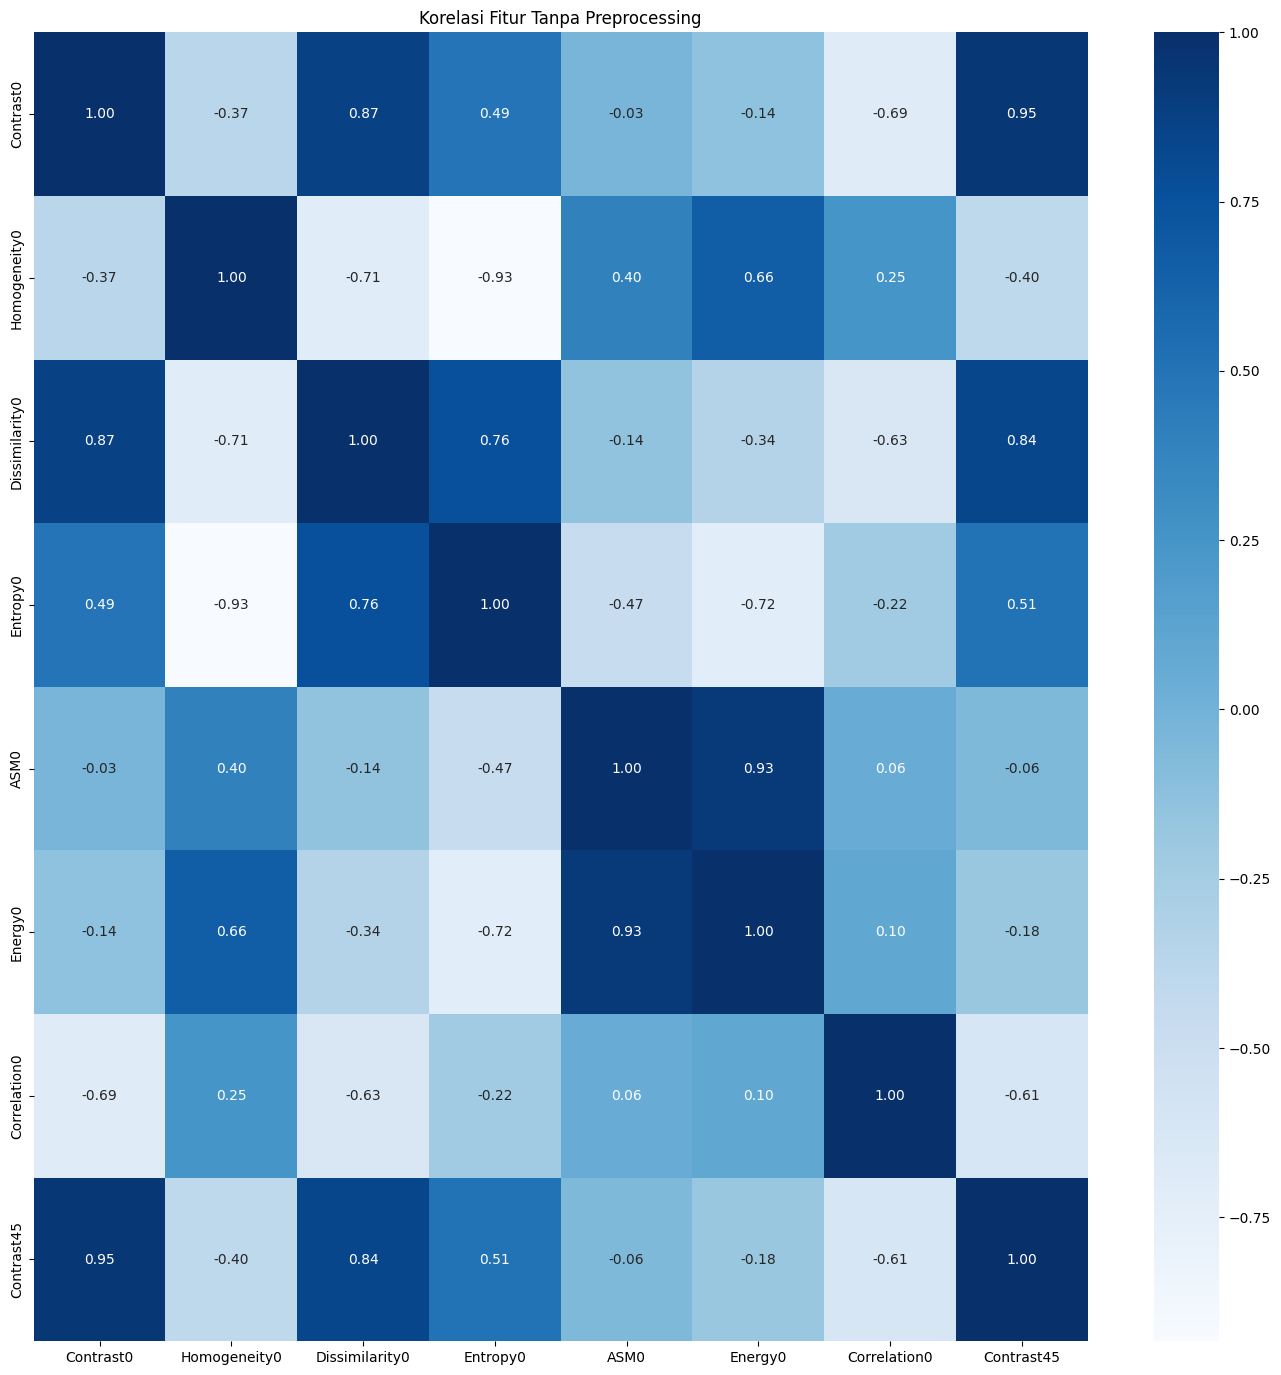

In [152]:
# Menghitung korelasi antar fitur numerik
feature_data = hasilEkstrak.drop(columns=["Label", "Filename"])
feature_data = feature_data.select_dtypes(include=[np.number])

correlation_matrix = feature_data.corr().abs()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = feature_data.columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak["Label"]

print("Jumlah fitur awal:", feature_data.shape[1])
print("Jumlah fitur setelah selection:", len(select))
print("Fitur yang digunakan:")
print(list(select))

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Korelasi Fitur Tanpa Preprocessing")
plt.show()

Cell ini memisahkan 28 fitur numerik dari `Label` dan `Filename`, lalu menghitung korelasi absolut antarfitur. Dengan ambang 0,95, fitur yang sangat berkorelasi dengan fitur terdahulu dihapus untuk mengurangi redundansi. Jumlah fitur berkurang dari 28 menjadi 8, yaitu `Contrast0`, `Homogeneity0`, `Dissimilarity0`, `Entropy0`, `ASM0`, `Energy0`, `Correlation0`, dan `Contrast45`. Seleksi ini terutama mempertahankan seluruh sifat tekstur pada arah 0° dan satu representasi contrast pada arah 45°, sehingga model menjadi lebih sederhana. Heatmap yang dihasilkan membantu memeriksa bahwa fitur tersisa tidak lagi memiliki pasangan dengan korelasi absolut sangat tinggi menurut aturan seleksi tersebut. Pada data raw, fitur lintas arah mudah berkorelasi tinggi karena noise, latar, dan pola intensitas yang sama dapat muncul di semua orientasi; karena itu penghapusan fitur redundan dapat menurunkan kompleksitas tanpa banyak kehilangan informasi. Akan tetapi, pendekatan ini tidak mengukur relevansi fitur terhadap label secara langsung, sehingga ada kemungkinan fitur yang informatif untuk membedakan kelas ikut terhapus karena berkorelasi dengan fitur lain. Hasil evaluasi berikutnya, terutama akurasi testing KNN 92,86% menunjukkan delapan fitur terpilih masih cukup diskriminatif untuk masalah ini, meskipun belum membuktikan bahwa kombinasi tersebut merupakan kombinasi terbaik.

## Splitting Data

In [153]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=45,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:")
print(y_train.value_counts())
print("y_test:")
print(y_test.value_counts())

X_train: (112, 8)
X_test: (28, 8)
y_train:
Label
snail           56
catterpillar    56
Name: count, dtype: int64
y_test:
Label
catterpillar    14
snail           14
Name: count, dtype: int64


Cell ini membagi data menggunakan `train_test_split` dengan `test_size=0.2`, `random_state=45`, dan `stratify=y`. Hasilnya adalah 112 sampel untuk training dan 28 sampel untuk testing. Stratifikasi menjaga setiap subset tetap seimbang: training berisi 56 catterpillar dan 56 snail, sedangkan testing berisi 14 citra untuk masing-masing kelas. Keseimbangan ini membuat precision, recall, F1-score, dan accuracy pada evaluasi kedua kelas dapat dibandingkan tanpa distorsi proporsi kelas. `random_state=45` membuat pembagian dapat direproduksi, sehingga eksperimen preprocessing atau parameter model berikutnya dapat dibandingkan pada pemisahan data yang sama. Namun, ukuran testing hanya 28 citra, sehingga satu kesalahan setara dengan sekitar 3,57 poin persentase akurasi dan perbedaan kecil antarmodel perlu ditafsirkan dengan hati-hati. Karena data raw tidak diaugmentasi, sampel testing tetap benar-benar terdiri dari citra asli yang tidak pernah dilihat pada training, tetapi jumlah variasi visual yang diuji masih terbatas. Nilai training dan testing pada cell model berikutnya mencerminkan kemampuan generalisasi pada split ini, bukan jaminan performa yang sama pada seluruh citra baru di luar dataset.

## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

In [154]:
# normalisasi mean std
std_train = X_train.std().replace(0, 1)
X_test = (X_test - X_train.mean()) / std_train
X_train = (X_train - X_train.mean()) / std_train

X_train.head()

,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45
83,-0.375360,-0.468082,-0.085850,0.433556,-0.294368,-0.468423,0.766826,-0.248061
95,-0.702957,0.484444,-0.876608,-0.573249,-0.040879,0.314010,0.986355,-0.660317
45,0.415482,-1.185694,0.906486,1.038122,-0.322125,-0.638724,-0.630187,0.298757
116,-0.937143,0.164936,-1.008213,-0.450641,-0.248318,-0.264815,1.005439,-0.851754
91,-0.610691,1.177713,-0.737343,-1.458225,0.505484,1.212600,0.458106,-0.525000


Cell ini menerapkan standardisasi Z-score menggunakan rata-rata dan standar deviasi dari `X_train`. `X_test` dinormalisasi menggunakan statistik training yang sama, sehingga prosedur ini benar dan mencegah kebocoran informasi statistik dari data test ke data train. Standar deviasi nol diganti dengan satu sebagai pengaman, meskipun pada delapan fitur terpilih tidak terlihat adanya fitur konstan. Output memperlihatkan nilai fitur training kini berpusat di sekitar nol dan dinyatakan dalam satuan simpangan baku, misalnya `Contrast0` dapat bernilai negatif atau positif. Normalisasi dilakukan setelah split, sehingga tidak mengubah citra raw maupun GLCM awal, melainkan hanya menyetarakan skala angka fitur sebelum pemodelan. Tahap ini sangat penting bagi KNN dan SVM, karena perbedaan skala awal, misalnya contrast ratusan dan ASM yang sangat kecil dapat membuat satu fitur mendominasi perhitungan jarak atau kernel. Random Forest relatif tidak membutuhkan standardisasi, tetapi penggunaan input yang sama tetap membuat perbandingan eksperimen lebih konsisten. Dengan demikian, hasil yang diperoleh adalah baseline tanpa preprocessing citra, tetapi bukan tanpa normalisasi fitur; normalisasi ini justru membantu model menghadapi skala fitur GLCM dari data raw.

## Modeling

### Define Model

In [155]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel="rbf", random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

hasil_model = []

Cell ini mendefinisikan fungsi pelaporan yang mencetak classification report, confusion matrix, dan accuracy untuk data training maupun testing. Tiga model digunakan sebagai pembanding: Random Forest dengan 5 pohon, SVM dengan kernel RBF, dan KNN dengan 5 tetangga terdekat. Random Forest dipilih untuk menangkap pola nonlinier melalui beberapa pohon keputusan, tetapi jumlah 5 estimator tergolong kecil sehingga hasilnya berpotensi belum stabil. SVM RBF dapat membentuk batas keputusan nonlinier pada fitur yang telah distandardisasi. KNN memutuskan kelas berdasarkan kedekatan lima data training, sehingga sangat dipengaruhi oleh kualitas normalisasi dan struktur lokal fitur GLCM raw. Semua model dilatih pada 112 sampel yang sama dan diuji pada 28 sampel yang sama, sehingga perbandingan metriknya langsung. Hasil tiap model disimpan ke `hasil_model` dengan precision, recall, dan F1 weighted untuk data testing. Karena label seimbang, weighted metrics pada percobaan ini dekat dengan macro metrics dan memberikan ringkasan yang cukup representatif terhadap kedua kelas.

### Train Random Forest Classifier

In [156]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_rf_train = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_rf_train)

print("\n------Testing Set------")
y_pred_rf_test = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf_test)

hasil_model.append({
    "Percobaan": "tanpa_preprocessing",
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_pred_rf_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_rf_test),
    "Precision": precision_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.95      0.95      0.95        56
       snail       0.95      0.95      0.95        56

    accuracy                           0.95       112
   macro avg       0.95      0.95      0.95       112
weighted avg       0.95      0.95      0.95       112

[[53  3]
 [ 3 53]]
Accuracy: 0.9464285714285714

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.81      0.93      0.87        14
       snail       0.92      0.79      0.85        14

    accuracy                           0.86        28
   macro avg       0.86      0.86      0.86        28
weighted avg       0.86      0.86      0.86        28

[[13  1]
 [ 3 11]]
Accuracy: 0.8571428571428571


Random Forest mencapai accuracy training **94,64%** dengan 106 prediksi benar dari 112 data training. Confusion matrix training `[[53, 3], [3, 53]]` menunjukkan masing-masing kelas mengalami tiga kesalahan, sehingga model mempelajari pola training secara kuat dan seimbang. Pada data testing, accuracy turun menjadi **85,71%** dengan 24 prediksi benar dari 28 sampel. Confusion matrix testing `[[13, 1], [3, 11]]` berarti satu catterpillar salah diprediksi sebagai snail, sedangkan tiga snail salah diprediksi sebagai catterpillar. Recall catterpillar mencapai **0,93**, sedangkan recall snail hanya **0,79**, jadi model lebih sering gagal mengenali snail pada split ini. Precision snail sebesar **0,92** menunjukkan ketika model memprediksi snail, prediksi tersebut umumnya tepat; namun sebagian snail justru tidak pernah diberi prediksi snail. Kesenjangan training-testing sekitar **8,93 poin persentase** mengindikasikan kecenderungan overfitting ringan, yang dapat dipengaruhi oleh fitur GLCM raw yang menangkap karakteristik spesifik citra training dan oleh jumlah pohon yang kecil. Tanpa preprocessing, noise, perubahan intensitas, dan latar belakang dapat memecah konsistensi tekstur snail sehingga tiga sampel snail testing lebih mudah tertarik ke pola catterpillar. Precision weighted **86,46%**, recall weighted **85,71%**, dan F1 weighted **85,64%** memperkuat bahwa model cukup baik tetapi generalisasinya belum sekuat hasil training. Untuk eksperimen lanjutan, peningkatan jumlah pohon dan preprocessing yang menekan noise atau menstabilkan kontras patut diuji pada split yang sama.

### Train SVM Classifier

In [157]:
# Train SVM Classifier
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_svm_train = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_svm_train)

print("\n------Testing Set------")
y_pred_svm_test = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm_test)

hasil_model.append({
    "Percobaan": "tanpa_preprocessing",
    "Model": "SVM",
    "Train Accuracy": accuracy_score(y_train, y_pred_svm_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_svm_test),
    "Precision": precision_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.82      0.80      0.81        56
       snail       0.81      0.82      0.81        56

    accuracy                           0.81       112
   macro avg       0.81      0.81      0.81       112
weighted avg       0.81      0.81      0.81       112

[[45 11]
 [10 46]]
Accuracy: 0.8125

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.76      0.93      0.84        14
       snail       0.91      0.71      0.80        14

    accuracy                           0.82        28
   macro avg       0.84      0.82      0.82        28
weighted avg       0.84      0.82      0.82        28

[[13  1]
 [ 4 10]]
Accuracy: 0.8214285714285714


SVM menghasilkan accuracy training **81,25%**, yaitu 91 prediksi benar dari 112 sampel. Confusion matrix training `[[45, 11], [10, 46]]` memperlihatkan kesalahan antarkelas cukup banyak dan relatif seimbang, sehingga model tidak terlalu menyesuaikan diri pada data training. Pada testing, accuracy menjadi **82,14%** atau 23 prediksi benar dari 28 sampel. Confusion matrix testing `[[13, 1], [4, 10]]` menunjukkan model mengenali 13 dari 14 catterpillar, tetapi hanya 10 dari 14 snail. Recall catterpillar **0,93** jauh lebih tinggi daripada recall snail **0,71**, menandakan batas keputusan SVM pada fitur raw lebih sering menggeser sampel snail ke kelas catterpillar. Precision catterpillar **0,76** lebih rendah dibanding precision snail **0,91**, karena cukup banyak prediksi catterpillar ternyata berasal dari snail. Selisih accuracy training dan testing hanya sekitar **0,89 poin persentase**, sehingga tidak ada indikasi overfitting yang kuat; masalah utamanya lebih dekat pada underfitting atau pemisahan fitur yang belum optimal. Variasi tekstur data raw yang belum disaring mungkin membuat dua kelas tumpang tindih pada ruang fitur delapan dimensi, sehingga kernel RBF dengan parameter default belum dapat membentuk pemisah yang memadai. Metrik testing weighted—precision **83,69%**, recall **82,14%**, dan F1 **81,94%**—menjadi yang terendah di antara tiga model. Percobaan selanjutnya dapat mengeksplorasi parameter `C` dan `gamma`, menambah fitur yang relevan, atau memakai preprocessing agar tekstur objek lebih konsisten sebelum diekstrak.

### Train KNN Classifier

In [158]:
# Train KNN Classifier
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_knn_train = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_knn_train)

print("\n------Testing Set------")
y_pred_knn_test = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn_test)

hasil_model.append({
    "Percobaan": "tanpa_preprocessing",
    "Model": "KNN",
    "Train Accuracy": accuracy_score(y_train, y_pred_knn_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_knn_test),
    "Precision": precision_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
})

df_hasil_model = pd.DataFrame(hasil_model)
print("Ringkasan hasil klasifikasi:")
df_hasil_model

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.86      0.79      0.82        56
       snail       0.80      0.88      0.84        56

    accuracy                           0.83       112
   macro avg       0.83      0.83      0.83       112
weighted avg       0.83      0.83      0.83       112

[[44 12]
 [ 7 49]]
Accuracy: 0.8303571428571429

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.88      1.00      0.93        14
       snail       1.00      0.86      0.92        14

    accuracy                           0.93        28
   macro avg       0.94      0.93      0.93        28
weighted avg       0.94      0.93      0.93        28

[[14  0]
 [ 2 12]]
Accuracy: 0.9285714285714286
Ringkasan hasil klasifikasi:


,Percobaan,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,tanpa_preprocessing,Random Forest,0.946429,0.857143,0.864583,0.857143,0.856410
1,tanpa_preprocessing,SVM,0.812500,0.821429,0.836898,0.821429,0.819355
2,tanpa_preprocessing,KNN,0.830357,0.928571,0.937500,0.928571,0.928205


KNN memperoleh accuracy training **83,04%**, atau 93 prediksi benar dari 112 sampel. Confusion matrix training `[[44, 12], [7, 49]]` menunjukkan KNN masih melakukan 19 kesalahan pada data latih, terutama catterpillar yang memiliki 12 prediksi salah sebagai snail. Pada data testing, KNN justru mencapai accuracy tertinggi, yaitu **92,86%** dengan 26 prediksi benar dari 28 sampel. Confusion matrix testing `[[14, 0], [2, 12]]` menunjukkan seluruh catterpillar testing dikenali tepat, sedangkan dua snail salah diprediksi sebagai catterpillar. Dengan demikian recall catterpillar adalah **1,00** dan recall snail **0,86**, sementara precision catterpillar **0,88** dan precision snail **1,00**. F1-score per kelas mencapai **0,93** untuk catterpillar dan **0,92** untuk snail, sedangkan F1 weighted adalah **92,82%**. Accuracy testing yang lebih tinggi sekitar **9,82 poin persentase** daripada training bukan pola yang biasa untuk menyimpulkan model lebih baik; paling mungkin split testing ini kebetulan lebih mudah atau lebih dekat dengan cluster training tertentu. Standardisasi fitur membuat jarak lima tetangga tidak didominasi oleh contrast yang berskala besar, sehingga KNN dapat memanfaatkan kedekatan gabungan delapan fitur GLCM raw dengan efektif. Namun, karena testing hanya 28 citra dan dua kesalahan saja sudah menurunkan accuracy 7,14 poin, hasil terbaik ini perlu dikonfirmasi memakai cross-validation atau beberapa nilai `random_state`. Pada split saat ini, KNN merupakan baseline raw-data terbaik, tetapi kestabilannya terhadap citra baru dengan noise, skala, atau pencahayaan berbeda belum dapat dipastikan.

## Evaluation With Confusion Matrix

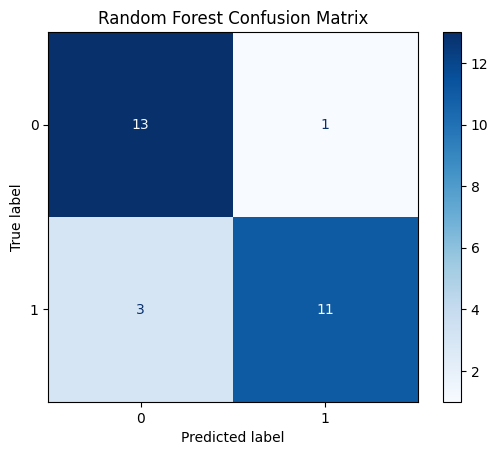

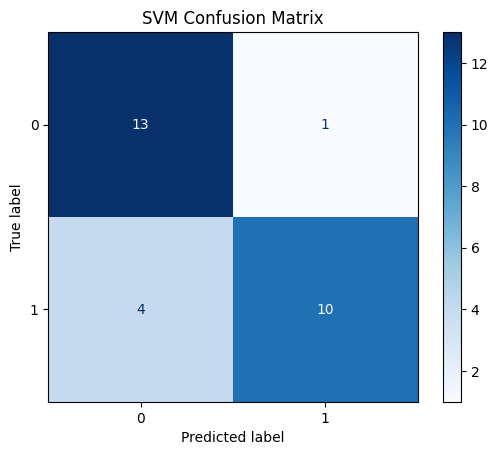

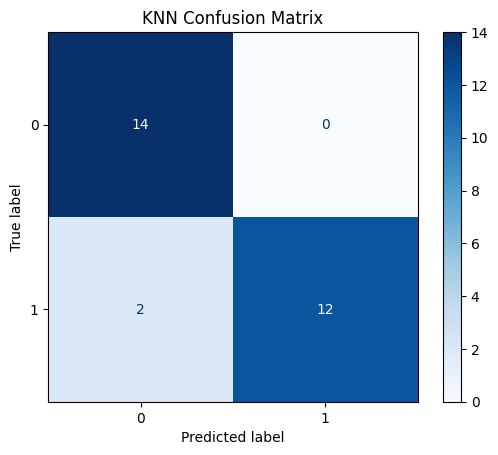

In [159]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_svm_test, "SVM Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_knn_test, "KNN Confusion Matrix")

Cell ini memvisualisasikan confusion matrix ketiga model pada data testing agar pola kesalahan per kelas lebih mudah dibaca. Random Forest menghasilkan 13/14 catterpillar dan 11/14 snail yang benar, sehingga kesalahan paling banyak muncul saat snail diprediksi sebagai catterpillar. SVM menghasilkan pola serupa tetapi lebih kuat, dengan 13/14 catterpillar dan hanya 10/14 snail yang benar. KNN memberikan matriks terbaik pada split ini: 14/14 catterpillar dan 12/14 snail dikenali dengan benar. Ketiga matriks tidak menunjukkan kesalahan catterpillar yang dominan; justru kelas snail lebih rentan tertukar menjadi catterpillar, terutama pada SVM dan Random Forest. Pola tersebut konsisten dengan data raw, karena variasi latar, tekstur cangkang, pencahayaan, atau detail nonobjek pada gambar snail dapat membuat fitur GLCM-nya tumpang tindih dengan kelas lain. Visualisasi ini juga menegaskan bahwa akurasi saja tidak cukup: KNN 92,86% tetap memiliki dua snail yang gagal dikenali, sebuah informasi penting bila prioritas sistem adalah mendeteksi semua snail. Hasil confusion matrix sebaiknya digunakan sebagai baseline saat membandingkan eksperimen preprocessing, dengan fokus apakah preprocessing mampu menaikkan recall snail tanpa menurunkan performa catterpillar.

## Kesimpulan
Percobaan ini berhasil membangun baseline klasifikasi dua kelas dari 140 citra raw yang seimbang, tanpa augmentation dan tanpa preprocessing citra seperti resize, median filtering, grayscale preprocessing, atau histogram equalization. Citra dikonversi menjadi grayscale hanya di dalam tahap ekstraksi GLCM untuk menghasilkan 28 fitur tekstur, lalu direduksi menjadi 8 fitur melalui seleksi korelasi dan distandardisasi setelah train-test split. Pada split 80:20 yang terstratifikasi, KNN memberikan hasil testing terbaik dengan accuracy **92,86%**, precision **93,75%**, recall **92,86%**, dan F1-score **92,82%**. Random Forest berada di urutan kedua dengan accuracy testing **85,71%** dan menunjukkan indikasi overfitting ringan karena accuracy training mencapai **94,64%**. SVM menjadi model terendah dengan accuracy testing **82,14%**, serta paling sering salah mengklasifikasikan snail sebagai catterpillar. Ketiadaan preprocessing membuat fitur GLCM tetap memuat karakteristik asli yang kaya, tetapi juga mewarisi noise, variasi pencahayaan, ukuran, dan latar belakang yang dapat memperlebar variasi dalam kelas serta menurunkan generalisasi. Karena ukuran data testing hanya 28 citra dan performa KNN testing bahkan melebihi training, hasil ini perlu divalidasi lagi dengan cross-validation atau split berulang. Baseline ini layak dipakai untuk mengukur pengaruh preprocessing berikutnya; preprocessing yang efektif diharapkan menghasilkan tekstur lebih konsisten, terutama meningkatkan recall kelas snail, dan memberikan hasil yang stabil pada beberapa pembagian data.